In [5]:
import os
import json
import cv2
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from PIL import Image
from wordcloud import WordCloud

In [ ]:
!pip install underthesea


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.0 MB/s eta 0:00:00


In [ ]:
# Chạy cell này xong, đợi nó báo "Session crashed" hoặc tự restart là xong.
!apt-get install -y fonts-liberation
!rm -rf ~/.cache/matplotlib

import os
import matplotlib.pyplot as plt

# Lệnh này sẽ ép Colab restart để nhận font mới cài
os.kill(os.getpid(), 9)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Thay đổi đường dẫn theo cấu trúc drive của bạn
JSON_PATH = "/content/drive/MyDrive/data/Caption/labels_final_v2.json"
IMAGE_FOLDER = "/content/drive/MyDrive/data/images"

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"✅ Tổng số lượng item trong JSON: {len(data)}")

✅ Tổng số lượng item trong JSON: 8000


Cell 3: Xử lý dữ liệu và Phân nhóm (Traffic, Street, Indoor)


In [7]:
rows = []
for item in tqdm(data, desc="Processing categories"):
    img_name = item['image']

    # Logic phân nhóm dựa trên số thứ tự tên file
    try:
        # Lấy số từ tên file, ví dụ "3050.jpg" -> 3050
        img_id = int(re.findall(r'\d+', img_name)[0])

        if 1 <= img_id <= 3000:
            category = 'Giao thông'
        elif 3001 <= img_id <= 6000:
            category = 'Đường phố'
        elif 6001 <= img_id <= 8000:
            category = 'Trong nhà'
        else:
            category = 'Khác'
    except:
        category = 'Không xác định'

    for cap in item['captions']:
        rows.append({
            'image': img_name,
            'caption': cap['caption'].lower(),
            'category': category,
            'word_count': len(cap['caption'].split())
        })

df = pd.DataFrame(rows)
print(f"\n✅ Đã tạo DataFrame với {len(df)} dòng dữ liệu.")
df.head()

Processing categories: 100%|██████████| 8000/8000 [00:00<00:00, 26172.77it/s]



✅ Đã tạo DataFrame với 40000 dòng dữ liệu.


,image,caption,category,word_count
0,00001.jpg,tuyến đường trải nhựa phía trước khá vắng vẻ v...,Giao thông,40
1,00001.jpg,đường phố hiện tại thoáng đãng với bức tường d...,Giao thông,37
2,00001.jpg,lòng đường rộng rãi có hàng cây cao to và một ...,Giao thông,41
3,00001.jpg,khung cảnh đường đi khá tĩnh lặng với lòng đườ...,Giao thông,40
4,00001.jpg,đường đi phía trước rợp bóng cây với phần vỉa ...,Giao thông,40


Cell 4: Biểu đồ 1 & 2 - Sự cân bằng và Độ dài Caption


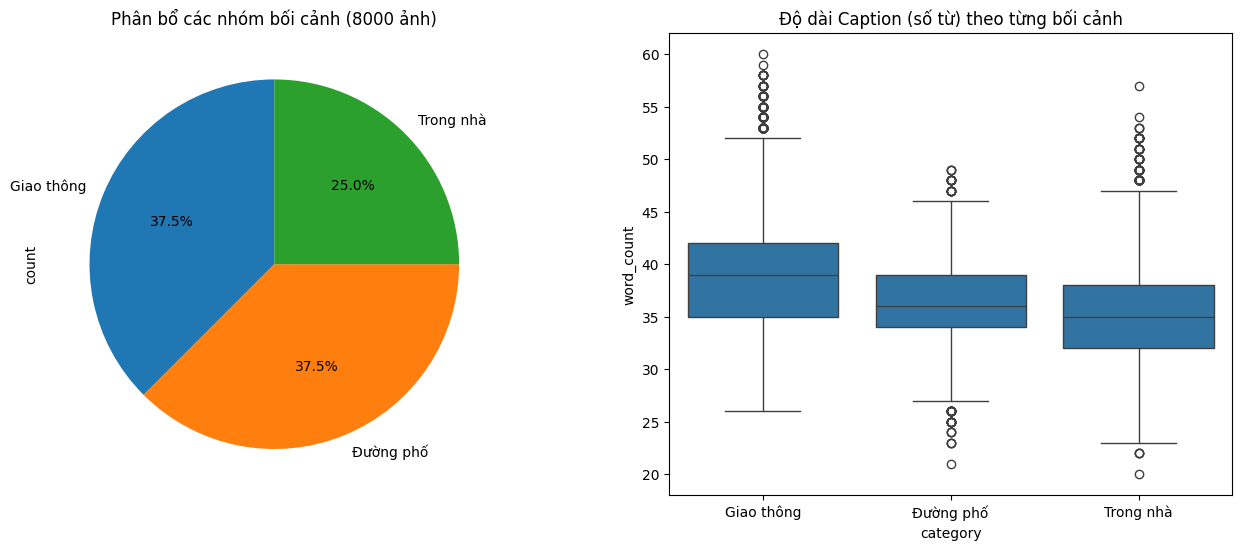

In [8]:
plt.figure(figsize=(16, 6))

# 1. Tỉ lệ các nhóm
plt.subplot(1, 2, 1)
df_unique = df.drop_duplicates('image')
df_unique['category'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("Phân bổ các nhóm bối cảnh (8000 ảnh)")

# 2. Độ dài từ theo nhóm
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='category', y='word_count')
plt.title("Độ dài Caption (số từ) theo từng bối cảnh")

plt.show()

Cell 5: Tự động trích xuất Vật cản và Hướng dựa trên Từ loại (POS Tagging)


Đang phân tích cú pháp: 100%|██████████| 1000/1000 [00:06<00:00, 154.43it/s]
/tmp/ipykernel_6075/2355428458.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(obj_c), y=list(obj_w), palette='Reds_r')
/tmp/ipykernel_6075/2355428458.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(dir_c), y=list(dir_w), palette='Blues_r')


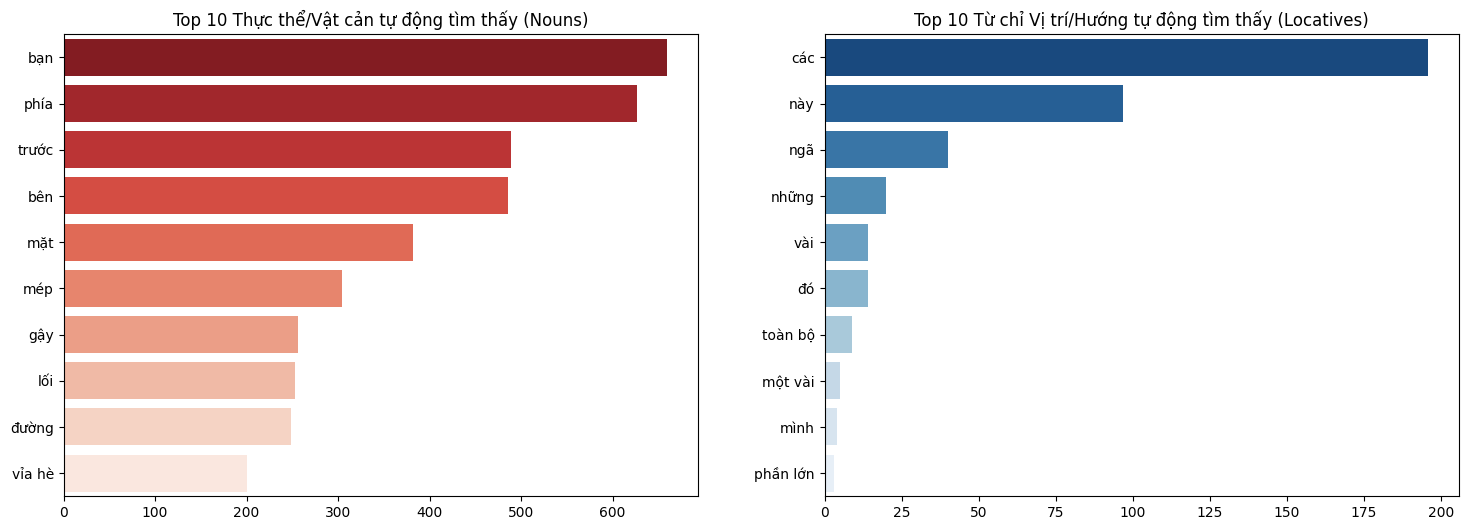

In [10]:
from underthesea import pos_tag
from collections import defaultdict

# 1. Hàm trích xuất tự động Nouns (Vật cản) và Locatives (Vị trí/Hướng)
def extract_auto_keywords(texts, limit=10):

    all_nouns = []
    all_dirs = []

    # Lấy mẫu 1000 câu để chạy POS tag cho nhanh (đại diện cho 8000 câu)
    sample_texts = np.random.choice(texts, min(1000, len(texts)), replace=False)

    for text in tqdm(sample_texts, desc="Đang phân tích cú pháp"):
        tagged = pos_tag(text)
        for word, tag in tagged:
            word = word.lower()
            if tag == 'N': # Danh từ - đại diện cho Vật thể/Vật cản
                if len(word) > 1: all_nouns.append(word)
            elif tag == 'L' or tag == 'P': # Từ chỉ vị trí/phương hướng hoặc Đại từ chỉ định
                all_dirs.append(word)

    return Counter(all_nouns).most_common(limit), Counter(all_dirs).most_common(limit)


# Chạy trích xuất cho toàn bộ Dataset
top_objects, top_directions = extract_auto_keywords(df['caption'].values)

# 2. Trực quan hóa kết quả tự động
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
obj_w, obj_c = zip(*top_objects)
sns.barplot(x=list(obj_c), y=list(obj_w), palette='Reds_r')
plt.title("Top 10 Thực thể/Vật cản tự động tìm thấy (Nouns)")

plt.subplot(1, 2, 2)
if top_directions:
    dir_w, dir_c = zip(*top_directions)
    sns.barplot(x=list(dir_c), y=list(dir_w), palette='Blues_r')
    plt.title("Top 10 Từ chỉ Vị trí/Hướng tự động tìm thấy (Locatives)")
else:
    plt.text(0.5, 0.5, "Không tìm thấy đủ từ chỉ hướng", ha='center')

plt.show()

NLP Parsing: 100%|██████████| 1500/1500 [00:07<00:00, 211.44it/s]
/tmp/ipykernel_6075/1683941752.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c for w,c in top_n], y=[w for w,c in top_n], ax=axes[0], palette='Reds_r')
/tmp/ipykernel_6075/1683941752.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c for w,c in top_l], y=[w for w,c in top_l], ax=axes[1], palette='Blues_r')


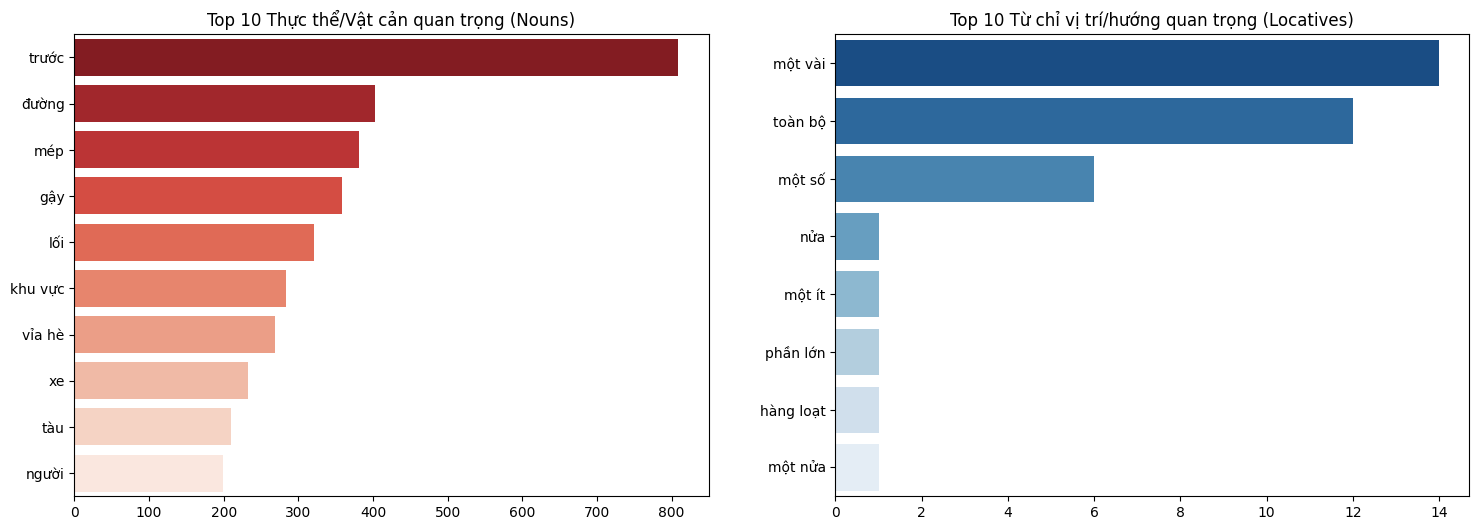

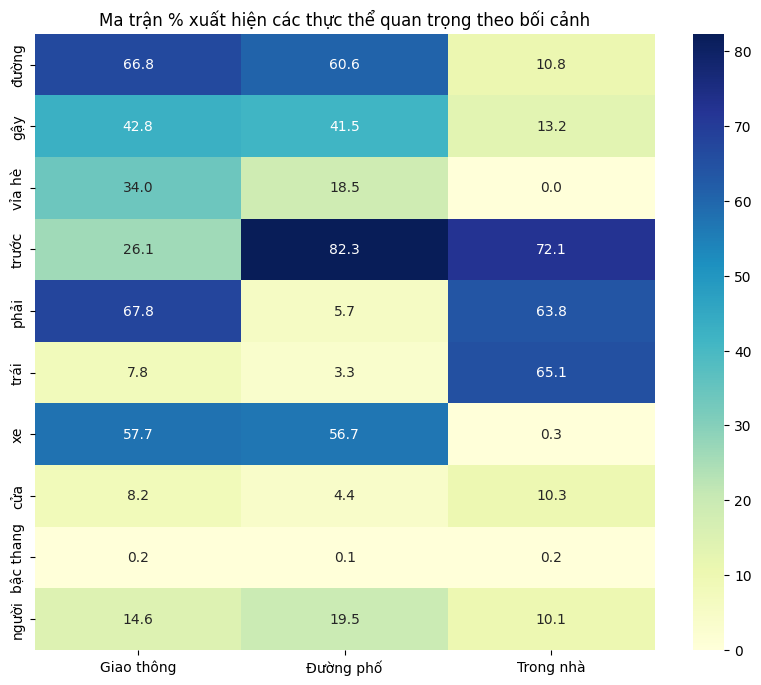

In [11]:
# --- BƯỚC 1: NLP PARSING (Giữ nguyên phần quét dữ liệu) ---
all_nouns, all_locatives = [], []
sample_captions = df['caption'].sample(min(1500, len(df))).values

for text in tqdm(sample_captions, desc="NLP Parsing"):
    tagged = pos_tag(text)
    for word, tag in tagged:
        if tag == 'N' and len(word) > 1: all_nouns.append(word)
        elif tag == 'L': all_locatives.append(word)

# --- BƯỚC 2: CHÈN ĐOẠN LỌC STOPWORDS Ở ĐÂY ---
# Danh sách này giúp loại bỏ các từ chung chung không mang giá trị mô tả vật cản
stopwords = [
    'bạn', 'phía', 'bên', 'mặt', 'các', 'này', 'những', 'vài', 'đó',
    'mình', 'một chút', 'mọi', 'vô số', 'hãy', 'đang', 'cho', 'của', 'được'
]

all_nouns = [w for w in all_nouns if w not in stopwords]
all_locatives = [w for w in all_locatives if w not in stopwords]

# --- BƯỚC 3: VẼ BIỂU ĐỒ CỘT (Sau khi đã lọc) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Lấy Top Nouns thực sự là vật cản (xe, gậy, vỉa hè, cửa, bàn...)
top_n = Counter(all_nouns).most_common(10)
sns.barplot(x=[c for w,c in top_n], y=[w for w,c in top_n], ax=axes[0], palette='Reds_r')
axes[0].set_title("Top 10 Thực thể/Vật cản quan trọng (Nouns)")

# Lấy Top Locatives thực sự là hướng (trước, trái, phải, trên, dưới...)
top_l = Counter(all_locatives).most_common(10)
sns.barplot(x=[c for w,c in top_l], y=[w for w,c in top_l], ax=axes[1], palette='Blues_r')
axes[1].set_title("Top 10 Từ chỉ vị trí/hướng quan trọng (Locatives)")

# --- BƯỚC 4: HEATMAP (Dùng danh sách từ khóa có ý nghĩa) ---
# Chúng ta chọn thủ công hoặc lấy các từ có độ tương quan cao để làm Insight
meaningful_keywords = ['đường', 'gậy', 'vỉa hè', 'trước', 'phải', 'trái', 'xe', 'cửa', 'bậc thang', 'người']

heatmap_data = []
for w in meaningful_keywords:
    row = [df[df['category'] == c]['caption'].str.contains(w).mean()*100 for c in ['Giao thông', 'Đường phố', 'Trong nhà']]
    heatmap_data.append(row)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f",
            xticklabels=['Giao thông', 'Đường phố', 'Trong nhà'],
            yticklabels=meaningful_keywords, cmap="YlGnBu")
plt.title("Ma trận % xuất hiện các thực thể quan trọng theo bối cảnh")
plt.show()

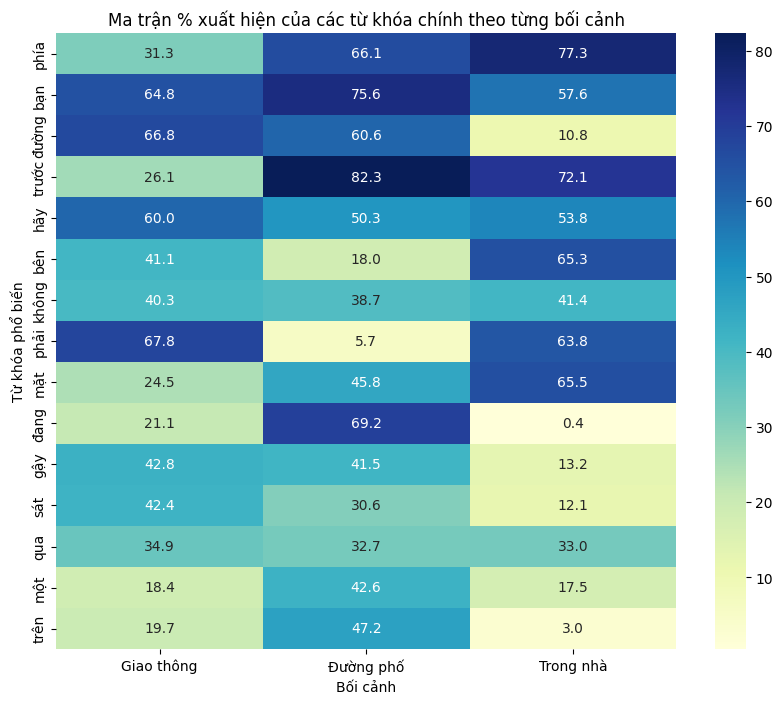

In [12]:
# Chọn ra top 15 từ xuất hiện nhiều nhất toàn bộ dataset (loại bỏ từ dừng)
top_common = [w for w, c in Counter(" ".join(df['caption']).split()).most_common(30) if len(w) > 2][:15]

# Tính toán tần suất của các từ này trong 3 nhóm
heatmap_data = []
for word in top_common:
    row = []
    for cat in ['Giao thông', 'Đường phố', 'Trong nhà']:
        # Tính % caption trong nhóm có chứa từ này
        count = df[df['category'] == cat]['caption'].str.contains(word).mean() * 100
        row.append(count)
    heatmap_data.append(row)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f",
            xticklabels=['Giao thông', 'Đường phố', 'Trong nhà'],
            yticklabels=top_common, cmap="YlGnBu")
plt.title("Ma trận % xuất hiện của các từ khóa chính theo từng bối cảnh")
plt.xlabel("Bối cảnh")
plt.ylabel("Từ khóa phổ biến")
plt.show()

Cell 6: Biểu đồ 5 - Phân tích Độ sáng (Visual Analysis)[link text](https://)


Calculating brightness for Trong nhà: 100%|██████████| 200/200 [00:01<00:00, 192.30it/s]


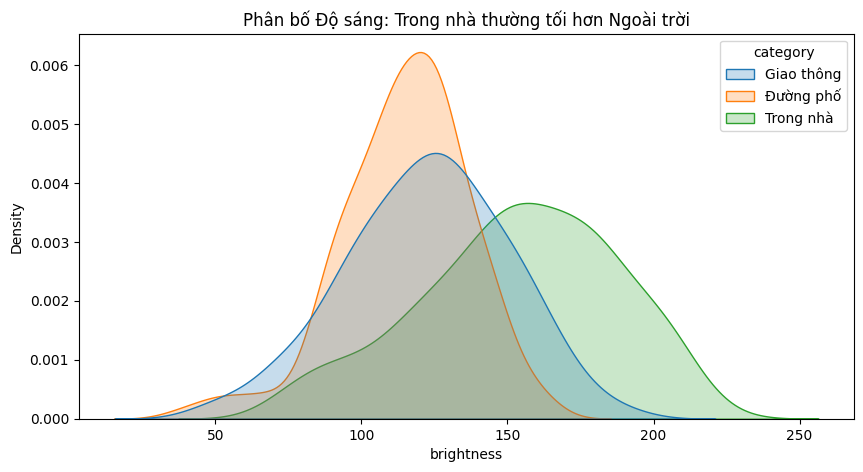

In [13]:
brightness_data = []
# Lấy mẫu mỗi nhóm 200 ảnh để chạy nhanh
for cat in ['Giao thông', 'Đường phố', 'Trong nhà']:
    sample_imgs = df[df['category'] == cat]['image'].unique()[:200]
    for img_n in tqdm(sample_imgs, desc=f"Calculating brightness for {cat}"):
        img_p = os.path.join(IMAGE_FOLDER, img_n)
        img = cv2.imread(img_p, 0)
        if img is not None:
            brightness_data.append({'category': cat, 'brightness': np.mean(img)})

br_df = pd.DataFrame(brightness_data)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=br_df, x='brightness', hue='category', fill=True)
plt.title("Phân bố Độ sáng: Trong nhà thường tối hơn Ngoài trời")
plt.show()

Cell 7: Biểu đồ 6 - Độ phức tạp ảnh (Edge Density)


Calculating edges for Trong nhà: 100%|██████████| 100/100 [00:00<00:00, 177.48it/s]


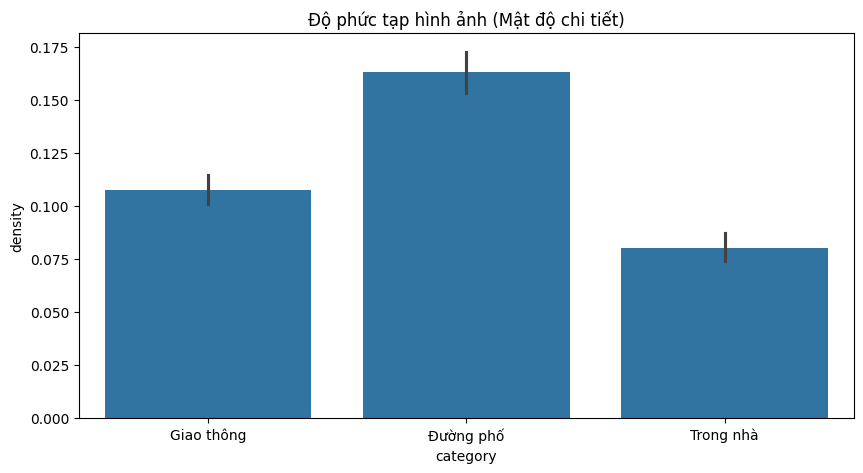

In [14]:
edge_data = []
for cat in ['Giao thông', 'Đường phố', 'Trong nhà']:
    sample_imgs = df[df['category'] == cat]['image'].unique()[:100]
    for img_n in tqdm(sample_imgs, desc=f"Calculating edges for {cat}"):
        img_p = os.path.join(IMAGE_FOLDER, img_n)
        img = cv2.imread(img_p, 0)
        if img is not None:
            edges = cv2.Canny(img, 100, 200)
            density = np.sum(edges > 0) / (img.shape[0] * img.shape[1])
            edge_data.append({'category': cat, 'density': density})

ed_df = pd.DataFrame(edge_data)
plt.figure(figsize=(10, 5))
sns.barplot(data=ed_df, x='category', y='density')
plt.title("Độ phức tạp hình ảnh (Mật độ chi tiết)")
plt.show()

Cell 8: Biểu đồ 7, 8, 9 - WordClouds theo từng Context


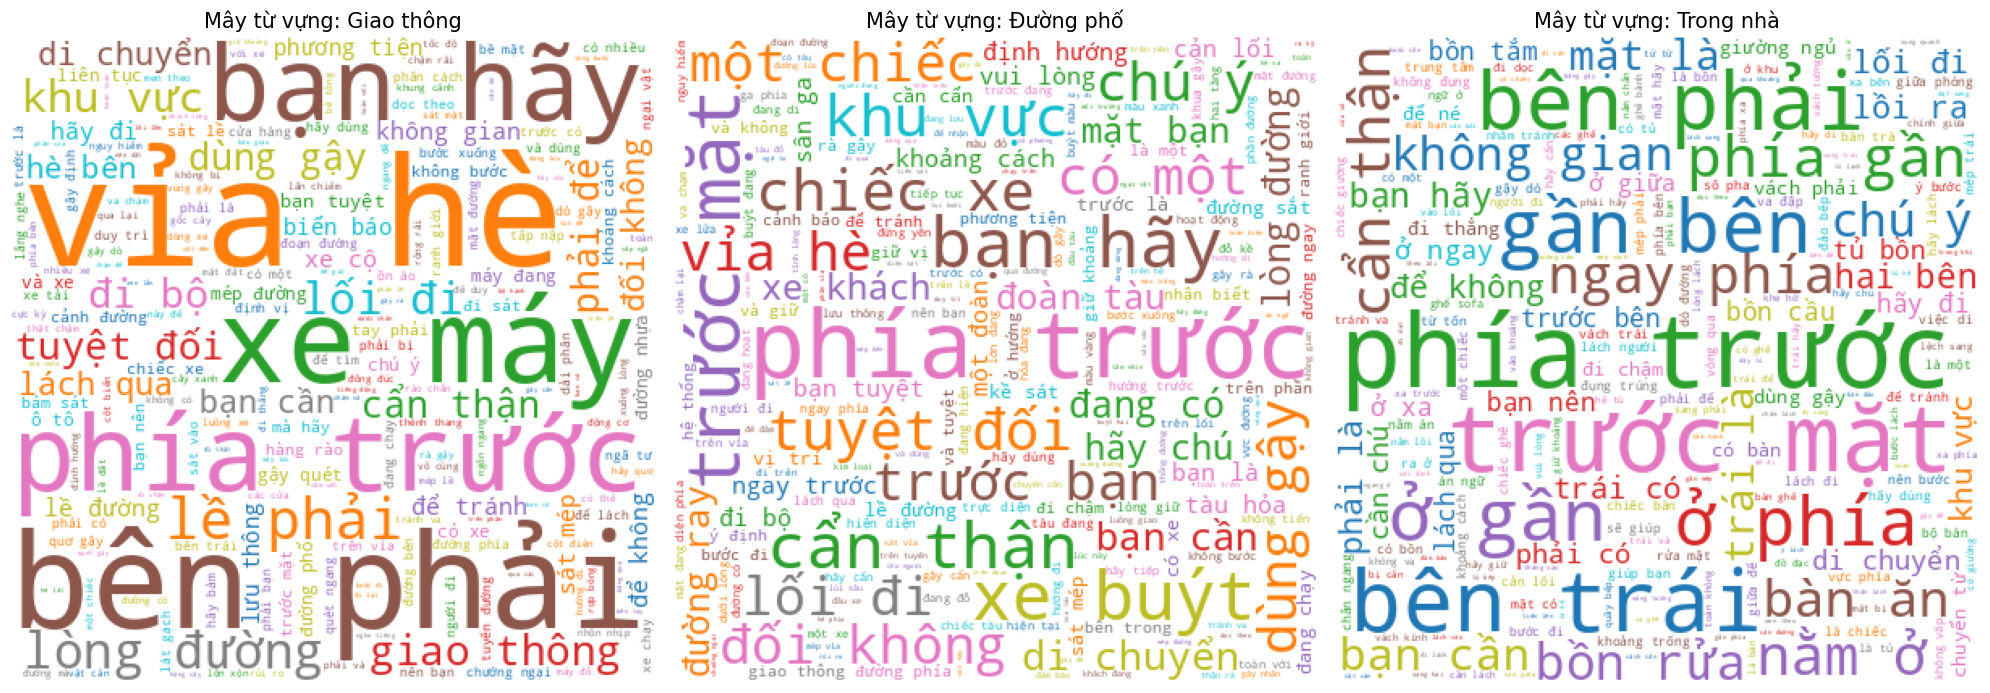

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
categories = ['Giao thông', 'Đường phố', 'Trong nhà']

for i, cat in enumerate(categories):
    text = " ".join(df[df['category'] == cat]['caption'].values)
    wc = WordCloud(width=400, height=400, background_color='white', colormap='tab10').generate(text)
    axes[i].imshow(wc)
    axes[i].axis('off')
    axes[i].set_title(f"Mây từ vựng: {cat}", fontsize=15)

plt.tight_layout()
plt.show()

Cell 9: Biểu đồ 10 - Top 20 Cụm từ (Bigrams) phổ biến nhất


/tmp/ipykernel_6075/491684007.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(b_counts), y=list(b_words), palette='flare')


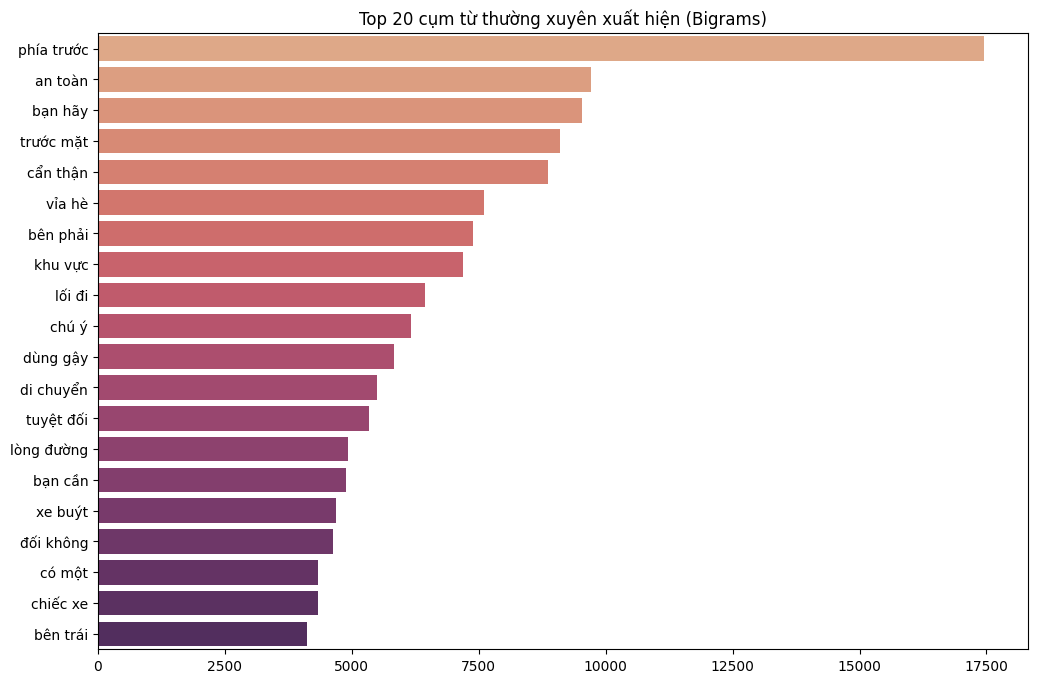

In [16]:
def get_top_bigrams(corpus, n=20):
    vec = Counter()
    for text in corpus:
        words = text.split()
        grams = [" ".join(words[i:i+2]) for i in range(len(words)-1)]
        vec.update(grams)
    return vec.most_common(n)

top_20_bigrams = get_top_bigrams(df['caption'])
b_words, b_counts = zip(*top_20_bigrams)

plt.figure(figsize=(12, 8))
sns.barplot(x=list(b_counts), y=list(b_words), palette='flare')
plt.title("Top 20 cụm từ thường xuyên xuất hiện (Bigrams)")
plt.show()

Cell 10: Xem mẫu dữ liệu ngẫu nhiên


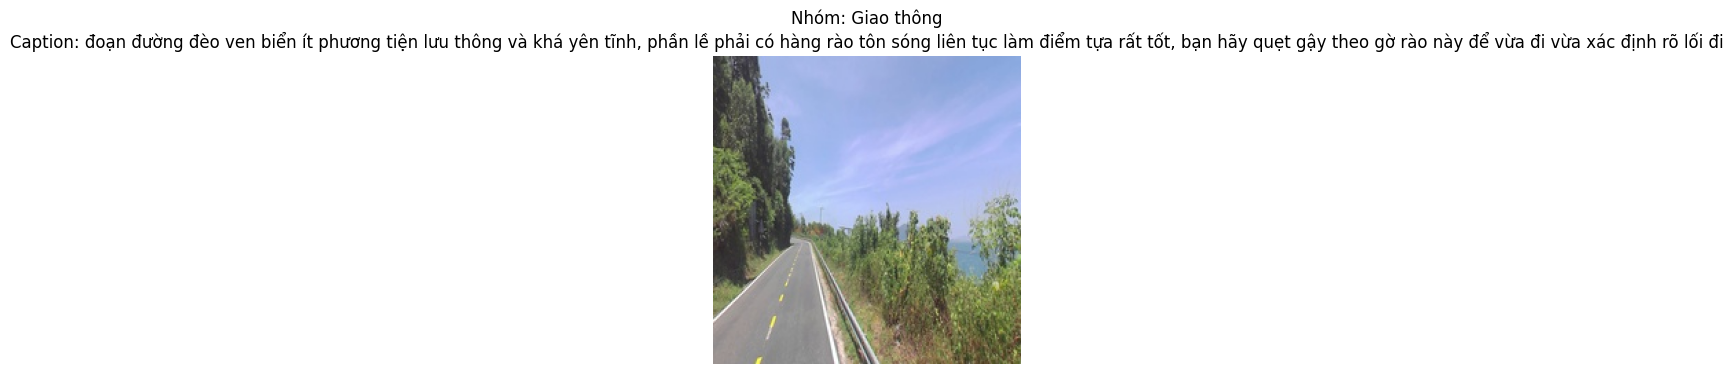

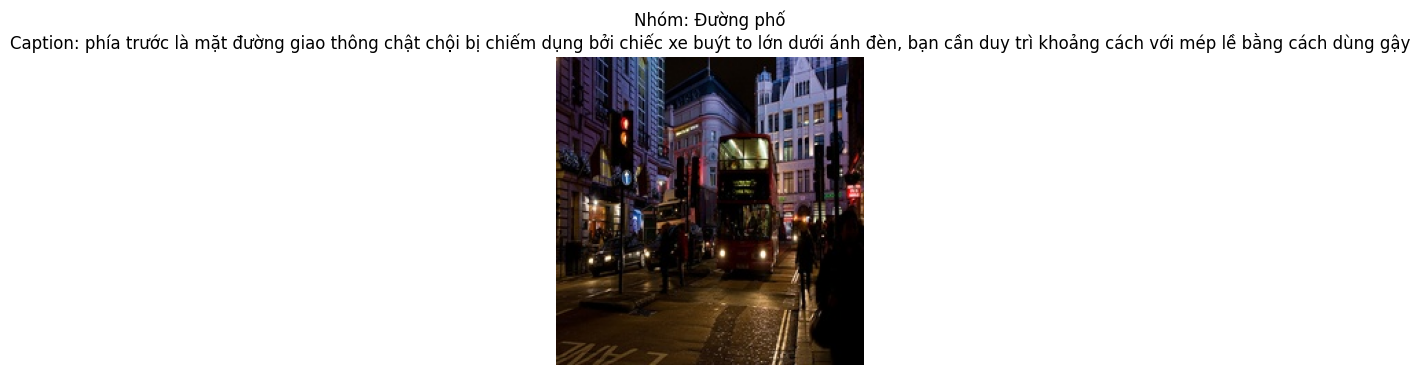

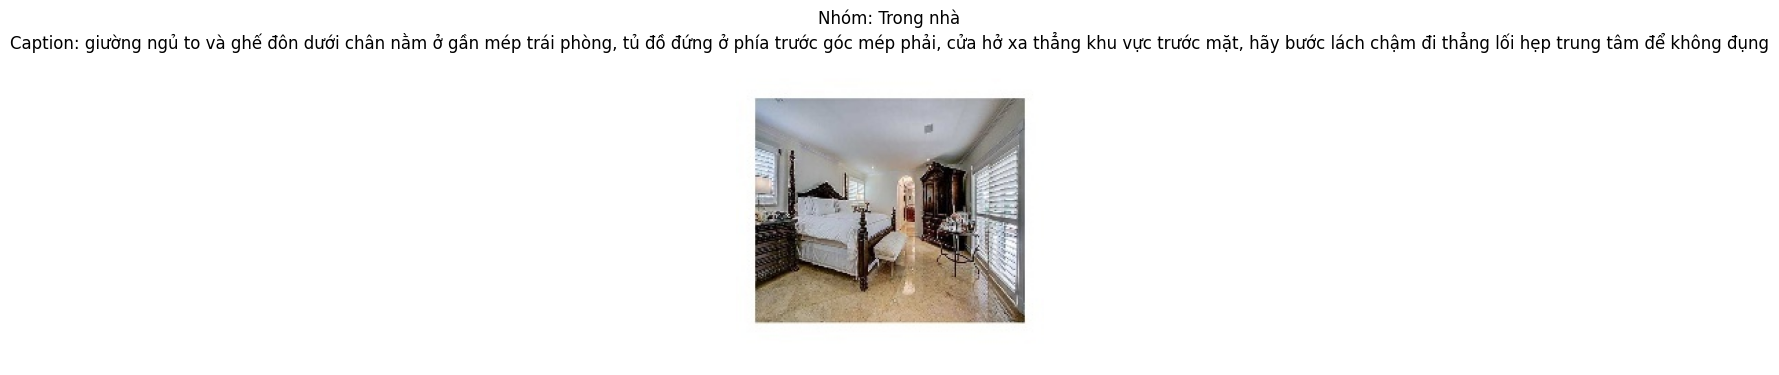

In [17]:
def preview_samples(category_name, num=2):
    sample_df = df[df['category'] == category_name].sample(num)
    for _, row in sample_df.iterrows():
        img_path = os.path.join(IMAGE_FOLDER, row['image'])
        img = Image.open(img_path)
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"Nhóm: {category_name}\nCaption: {row['caption']}")
        plt.axis('off')
        plt.show()

# Xem mẫu mỗi nhóm
for c in ['Giao thông', 'Đường phố', 'Trong nhà']:
    preview_samples(c, 1)